In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=32
paradigm = P300(resample=sfreq, tmin=-0.2, tmax=1, fmin=0.1, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014008()
subject, session, run = 1, "session_0", "run_0"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,-0.188 – 0.969 sec
Baseline,off


Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.


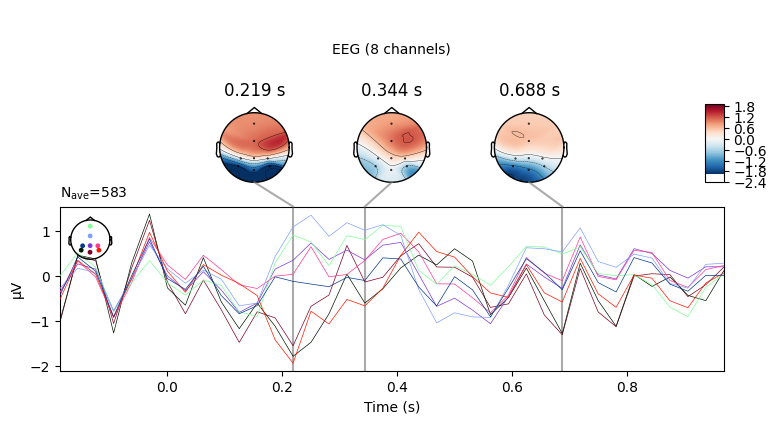

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
contrast.apply_baseline((-0.2,0))
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
split = len(epochs)//2
epochs_train = epochs[:split]
epochs_test = epochs[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('cupy')

X_train = tl.tensor(epochs_train.get_data().astype(np.float32))
y_train = labels_train=='Target'
X_test = tl.tensor(epochs_test.get_data().astype(np.float32))
y_test = labels_test=='Target'

X_train /= np.std(X_train, axis=0)[np.newaxis,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:]

In [ ]:
hoda = HODA(
    max_iter=128,
    rank=[2,4],
    tol=1e-6,
    init ='svd',
    verbose=True,
    shrinkage=('oas', 'oas'),
    toeplitz=(1,),
    solver='ratio_svd',
    fisher_thresh=0,
    keep_train_score=True,
)
#%lprun -f  hoda.fit hoda.fit(X_train,y_train)
hoda.fit(X_train,y_train)

  0%|          | 0/128 [00:00<?, ?it/s]

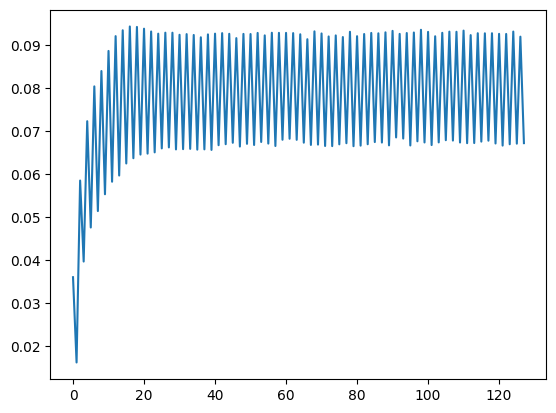

In [14]:
import cupy

plt.plot(cupy.asnumpy(hoda.train_score_))

In [10]:
import cupy

feature_score = cupy.asnumpy(hoda.feature_score(X_train, y_train))
sns.heatmap(feature_fisher_score)

NameError: name 'feature_fisher_score' is not defined

In [ ]:
sns.distplot(feature_fisher_score, kde=False)
plt.axvline(hoda.fisher_thresh, color='red')

In [ ]:
fig, axs = plt.subplots(1,hoda.rank_[0], figsize=(16,6))
axs = np.atleast_1d(axs)

for i in range(hoda.rank_[0]):
    w = cupy.asnumpy(hoda.projs_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[i], show=False)
vmax = np.max(np.abs(hoda.projs_[1]))
fig, axs = plt.subplots(1,hoda.rank_[1], figsize=(16,6))
axs = np.atleast_1d(axs)

for i in range(hoda.rank_[1]):
    w = cupy.asnumpy(hoda.projs_[1][:,i])
    axs[i].plot(epochs.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')
    axs[i].set_ylim([-vmax, vmax])


In [ ]:
sns.heatmap(cupy.asnumpy(hoda.fisher_score_), vmin=0)

In [ ]:
for k in range(2):
    cov = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

In [ ]:
for k in range(2):
    cov = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

In [ ]:
patterns = [hoda.scatter_w_[k] @ p for k,p in enumerate(hoda.projs_)]

fig, axs = plt.subplots(1,hoda.rank_[0], figsize=(16,6))
axs = np.atleast_1d(axs)
for i in range(hoda.rank_[0]):
    w = cupy.asnumpy(patterns[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[i], show=False)
vmax = np.max(np.abs(patterns[1]))
fig, axs = plt.subplots(1,hoda.rank_[1], figsize=(16,6))
axs = np.atleast_1d(axs)
for i in range(hoda.rank_[1]):
    w = cupy.asnumpy(patterns[1][:,i])
    axs[i].plot(epochs.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')
    axs[i].set_ylim([-vmax, vmax])

In [ ]:
from mne import EvokedArray

core = hoda.transform(X_train)
core = core[y_train].mean(axis=0)-core[~y_train].mean(axis=0)
w_sp = hoda.projs_[0]
w_tmp = hoda.projs_[1]
weights = cupy.asnumpy(w_sp) @ core @ cupy.asnumpy(w_tmp.T)
weights_evoked = EvokedArray(weights, epochs.info, epochs.tmin)
_ = weights_evoked.plot_joint()

In [ ]:
Xt_train = cupy.asnumpy(hoda.transform(X_train))
Xt_test = cupy.asnumpy(hoda.transform(X_test))
flat_mask = cupy.asnumpy(hoda.feature_mask_.flatten()).astype(bool)

Xt_train = Xt_train.reshape((Xt_train.shape[0],-1))[:, flat_mask]
Xt_test = Xt_test.reshape((Xt_test.shape[0],-1))[:, flat_mask]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.svm import SVC

classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)


In [ ]:
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()
f1 = feature_order[0]
f2 = feature_order[1]

In [ ]:
import seaborn as sns

g = sns.jointplot(x=Xt_train[:,f1],y=Xt_train[:,f2], hue=y_train)

In [ ]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

In [ ]:
g = sns.jointplot(x=Xt_test[:,f1],y=Xt_test[:,f2], hue=y_test)

In [ ]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])